## 1. Setup and Data Loading

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [ ]:
# Load the training data
data_path = 'training_data_phase5_1235records_fixed.csv'
df = pd.read_csv(data_path)

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset loaded successfully!
Shape: 1235 rows × 31 columns
Memory usage: 0.88 MB


## 2. Initial Data Overview

In [4]:
# Display first few rows
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,asset_id,purchase_date,device_type,department,region,brand,model_year,age_in_months,battery_cycles,battery_health_percent,smart_sectors_reallocated,thermal_events_count,daily_usage_hours,usage_type,os,overheating_issues,performance_rating,total_incidents,critical_incidents,high_incidents,medium_incidents,low_incidents,avg_resolution_time_hours,incident_rate_per_month,critical_incident_ratio,battery_degradation_rate,thermal_events_per_month,risk_score,risk_label,data_completeness,created_at
0,LAP-0001,2023-03-16 15:45:16.302142,laptop,Engineering,US,HP,2021,36,420,86.0000,74,3,6.0000,Office,Windows,False,4,3,0,0,1,2,6.5800,1.0000,0.0000,0.3890,0.0830,0.3000,high,1.0000,2026-02-28 15:45:16.302142
1,LAP-0002,2022-03-21 15:45:16.302690,laptop,Engineering,India,Dell,2020,48,610,78.0000,91,24,8.0000,Programming,Windows,True,3,6,0,1,2,3,8.5600,2.0000,0.0000,0.4580,0.5000,0.4930,high,1.0000,2026-02-28 15:45:16.303064
2,LAP-0003,2024-03-10 15:45:16.303064,laptop,Finance,India,Apple,2022,24,310,92.0000,56,2,7.0000,Creative,macOS,False,5,1,0,0,0,1,2.6100,0.3300,0.0000,0.3330,0.0830,0.2000,high,1.0000,2026-02-28 15:45:16.303626
3,LAP-0004,2021-03-26 15:45:16.303626,laptop,Engineering,EU,Lenovo,2019,60,700,70.0000,100,48,5.0000,Student,Windows,True,3,5,0,1,2,2,11.3000,1.6700,0.0000,0.5000,0.8000,0.6420,high,1.0000,2026-02-28 15:45:16.303626
4,LAP-0005,2022-11-16 15:45:16.304136,laptop,IT,US,Asus,2021,40,820,65.0000,100,33,9.0000,Gaming,Windows,True,2,8,0,1,3,4,5.5000,2.6700,0.0000,0.8750,0.8250,0.5830,high,1.0000,2026-02-28 15:45:16.304136
5,LAP-0006,2022-01-20 15:45:16.304136,laptop,Finance,India,Acer,2020,50,540,80.0000,100,7,6.0000,Office,Windows,False,4,3,0,0,1,2,7.4800,1.0000,0.0000,0.4000,0.1400,0.4120,high,1.0000,2026-02-28 15:45:16.304136
6,LAP-0007,2024-09-06 15:45:16.304690,laptop,Engineering,US,Apple,2023,18,210,95.0000,38,8,8.0000,Programming,macOS,False,5,0,0,0,0,0,0.0000,0.0000,0.0000,0.2780,0.4440,0.1580,low,1.0000,2026-02-28 15:45:16.304690
7,LAP-0008,2020-03-31 15:45:16.304690,laptop,HR,EU,HP,2018,72,880,60.0000,100,13,4.0000,Student,Windows,True,2,8,0,1,3,4,7.3400,2.6700,0.0000,0.5560,0.1810,0.5820,high,1.0000,2026-02-28 15:45:16.304690
8,LAP-0009,2023-09-12 15:45:16.305225,laptop,Finance,India,Dell,2022,30,350,88.0000,67,7,6.0000,Office,Windows,False,4,5,0,0,2,3,8.3200,1.6700,0.0000,0.4000,0.2330,0.3040,high,1.0000,2026-02-28 15:45:16.305225
9,LAP-0010,2023-03-16 15:45:16.305225,laptop,Sales,EU,Lenovo,2021,36,480,83.0000,78,6,7.0000,Programming,Windows,False,4,3,0,0,1,2,7.6600,1.0000,0.0000,0.4720,0.1670,0.3280,high,1.0000,2026-02-28 15:45:16.305763


In [5]:
# Dataset information
print("Dataset Information:")
print("=" * 80)
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1235 entries, 0 to 1234
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   asset_id                   1235 non-null   str    
 1   purchase_date              1235 non-null   str    
 2   device_type                1235 non-null   str    
 3   department                 1235 non-null   str    
 4   region                     1235 non-null   str    
 5   brand                      1235 non-null   str    
 6   model_year                 1235 non-null   int64  
 7   age_in_months              1235 non-null   int64  
 8   battery_cycles             1235 non-null   int64  
 9   battery_health_percent     1235 non-null   float64
 10  smart_sectors_reallocated  1235 non-null   int64  
 11  thermal_events_count       1235 non-null   int64  
 12  daily_usage_hours          1235 non-null   float64
 13  usage_type                 1235 non-nu

In [6]:
# Column names and data types
print("\nColumn Overview:")
print("=" * 80)
column_info = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.count().values,
    'Null Count': df.isnull().sum().values,
    'Unique Values': df.nunique().values
})
column_info


Column Overview:


,Column,Data Type,Non-Null Count,Null Count,Unique Values
0,asset_id,str,1235,0,1235
1,purchase_date,str,1235,0,950
2,device_type,str,1235,0,1
3,department,str,1235,0,6
4,region,str,1235,0,3
5,brand,str,1235,0,6
6,model_year,int64,1235,0,8
7,age_in_months,int64,1235,0,23
8,battery_cycles,int64,1235,0,214
9,battery_health_percent,float64,1235,0,724


## 3. Data Completeness Analysis

In [7]:
# Missing values analysis
print("Missing Values Analysis:")
print("=" * 80)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_data) > 0:
    print(f"\nColumns with missing values: {len(missing_data)}")
    display(missing_data)
else:
    print("\n✓ No missing values found in the dataset!")

Missing Values Analysis:

✓ No missing values found in the dataset!


In [8]:
# Visualize missing data (if any)
if len(missing_data) > 0:
    plt.figure(figsize=(12, 6))
    plt.barh(missing_data['Column'], missing_data['Missing Percentage'])
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Data by Column')
    plt.tight_layout()
    plt.show()

In [9]:
# Check data completeness field
if 'data_completeness' in df.columns:
    print("\nData Completeness Distribution:")
    print("=" * 80)
    print(df['data_completeness'].describe())
    print(f"\nRecords with 100% completeness: {(df['data_completeness'] == 1.0).sum()} ({(df['data_completeness'] == 1.0).sum() / len(df) * 100:.2f}%)")
    print(f"Records with < 100% completeness: {(df['data_completeness'] < 1.0).sum()} ({(df['data_completeness'] < 1.0).sum() / len(df) * 100:.2f}%)")


Data Completeness Distribution:
count   1235.0000
mean       1.0000
std        0.0000
min        1.0000
25%        1.0000
50%        1.0000
75%        1.0000
max        1.0000
Name: data_completeness, dtype: float64

Records with 100% completeness: 1235 (100.00%)
Records with < 100% completeness: 0 (0.00%)


## 4. Statistical Summary

In [10]:
# Statistical summary for numerical features
print("Statistical Summary - Numerical Features:")
print("=" * 80)
df.describe().T

Statistical Summary - Numerical Features:


,count,mean,std,min,25%,50%,75%,max
model_year,1235.0000,2025.6980,1.1345,2018.0000,2026.0000,2026.0000,2026.0000,2026.0000
age_in_months,1235.0000,7.9951,8.5763,1.0000,4.0000,7.0000,10.0000,72.0000
battery_cycles,1235.0000,148.4486,101.2141,100.0000,100.0000,102.0000,163.0000,950.0000
battery_health_percent,1235.0000,53.0814,14.4821,40.0000,40.0000,48.5400,62.8300,98.0000
smart_sectors_reallocated,1235.0000,43.9684,21.5641,0.0000,28.0000,47.0000,58.0000,100.0000
thermal_events_count,1235.0000,12.9887,13.8875,0.0000,3.0000,7.0000,19.0000,50.0000
daily_usage_hours,1235.0000,6.7762,2.6154,3.0000,4.5000,6.4000,8.9000,12.0000
performance_rating,1235.0000,2.3854,1.2180,1.0000,2.0000,2.0000,4.0000,5.0000
total_incidents,1235.0000,9.3547,4.9332,0.0000,5.0000,10.0000,12.0000,20.0000
critical_incidents,1235.0000,0.0113,0.1059,0.0000,0.0000,0.0000,0.0000,1.0000


In [11]:
# Statistical summary for categorical features
print("\nStatistical Summary - Categorical Features:")
print("=" * 80)
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns
if len(categorical_cols) > 0:
    df[categorical_cols].describe().T
else:
    print("No categorical columns found")


Statistical Summary - Categorical Features:


## 5. Target Variable Analysis

Risk Label Distribution:
            Count  Percentage
risk_label                   
high         1092     88.4200
medium        120      9.7200
low            23      1.8600


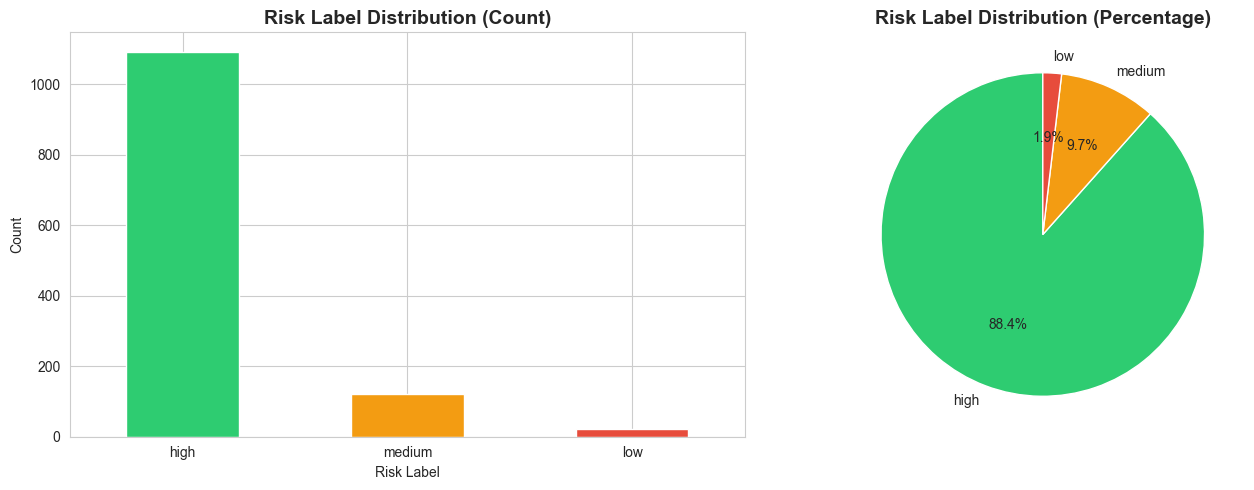


Class Imbalance Analysis:
Imbalance Ratio: 47.48x
⚠️  WARNING: Significant class imbalance detected! Consider using balancing techniques.


In [12]:
# Analyze risk_label distribution (target variable)
if 'risk_label' in df.columns:
    print("Risk Label Distribution:")
    print("=" * 80)
    
    risk_dist = df['risk_label'].value_counts()
    risk_pct = df['risk_label'].value_counts(normalize=True) * 100
    
    risk_summary = pd.DataFrame({
        'Count': risk_dist,
        'Percentage': risk_pct.round(2)
    })
    
    print(risk_summary)
    
    # Visualize distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    risk_dist.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#f39c12', '#e74c3c'])
    axes[0].set_title('Risk Label Distribution (Count)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Risk Label')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=0)
    
    # Pie chart
    axes[1].pie(risk_dist, labels=risk_dist.index, autopct='%1.1f%%', startangle=90,
                colors=['#2ecc71', '#f39c12', '#e74c3c'])
    axes[1].set_title('Risk Label Distribution (Percentage)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Check for class imbalance
    max_class_pct = risk_pct.max()
    min_class_pct = risk_pct.min()
    imbalance_ratio = max_class_pct / min_class_pct
    
    print(f"\nClass Imbalance Analysis:")
    print(f"Imbalance Ratio: {imbalance_ratio:.2f}x")
    if imbalance_ratio > 3:
        print("⚠️  WARNING: Significant class imbalance detected! Consider using balancing techniques.")
    elif imbalance_ratio > 1.5:
        print("⚠️  Moderate class imbalance present.")
    else:
        print("✓ Classes are relatively balanced.")


Risk Score Distribution:
count   1235.0000
mean       0.3674
std        0.1422
min        0.0500
25%        0.2735
50%        0.3740
75%        0.4730
max        0.7230
Name: risk_score, dtype: float64


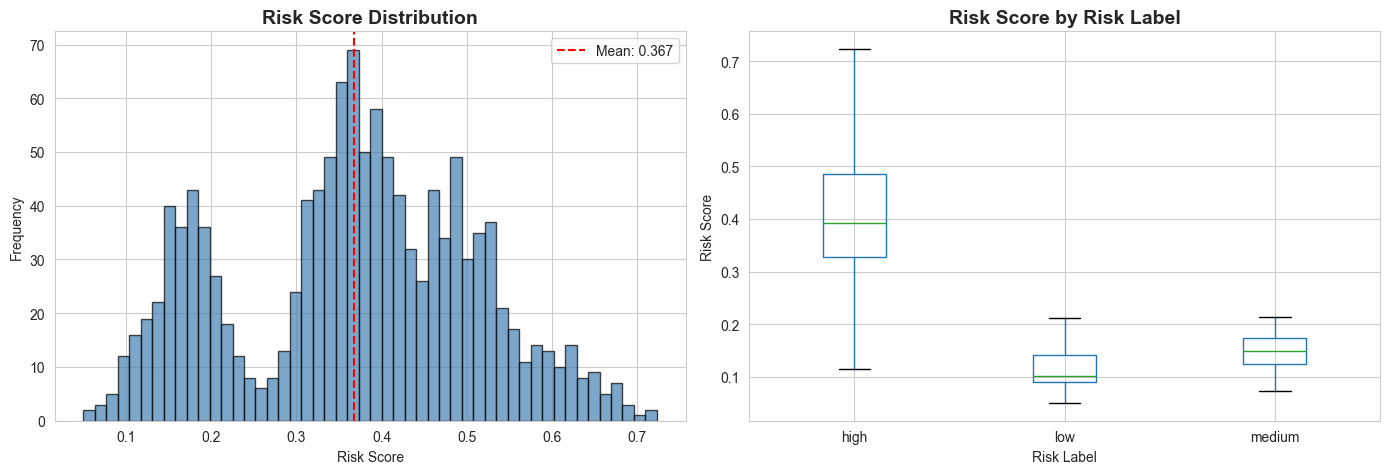

In [13]:
# Analyze risk_score distribution
if 'risk_score' in df.columns:
    print("\nRisk Score Distribution:")
    print("=" * 80)
    print(df['risk_score'].describe())
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(df['risk_score'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].set_title('Risk Score Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Risk Score')
    axes[0].set_ylabel('Frequency')
    axes[0].axvline(df['risk_score'].mean(), color='red', linestyle='--', label=f'Mean: {df["risk_score"].mean():.3f}')
    axes[0].legend()
    
    # Box plot by risk label
    if 'risk_label' in df.columns:
        df.boxplot(column='risk_score', by='risk_label', ax=axes[1])
        axes[1].set_title('Risk Score by Risk Label', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Risk Label')
        axes[1].set_ylabel('Risk Score')
        plt.suptitle('')  # Remove default title
    
    plt.tight_layout()
    plt.show()

## 6. Categorical Features Analysis

In [14]:
# Analyze key categorical features
categorical_features = ['device_type', 'department', 'region', 'brand', 'usage_type', 'os', 'overheating_issues']
categorical_features = [col for col in categorical_features if col in df.columns]

print("Categorical Features Distribution:")
print("=" * 80)

for col in categorical_features:
    print(f"\n{col.upper()}:")
    value_counts = df[col].value_counts()
    value_pct = df[col].value_counts(normalize=True) * 100
    
    summary = pd.DataFrame({
        'Count': value_counts,
        'Percentage': value_pct.round(2)
    })
    print(summary)
    print("-" * 60)

Categorical Features Distribution:

DEVICE_TYPE:
             Count  Percentage
device_type                   
laptop        1235    100.0000
------------------------------------------------------------

DEPARTMENT:
             Count  Percentage
department                    
Engineering    313     25.3400
IT             243     19.6800
Sales          243     19.6800
HR             204     16.5200
Finance        117      9.4700
Operations     115      9.3100
------------------------------------------------------------

REGION:
        Count  Percentage
region                   
India     481     38.9500
US        457     37.0000
EU        297     24.0500
------------------------------------------------------------

BRAND:
        Count  Percentage
brand                    
Acer      220     17.8100
Apple     212     17.1700
Dell      205     16.6000
Asus      203     16.4400
HP        200     16.1900
Lenovo    195     15.7900
-----------------------------------------------------------

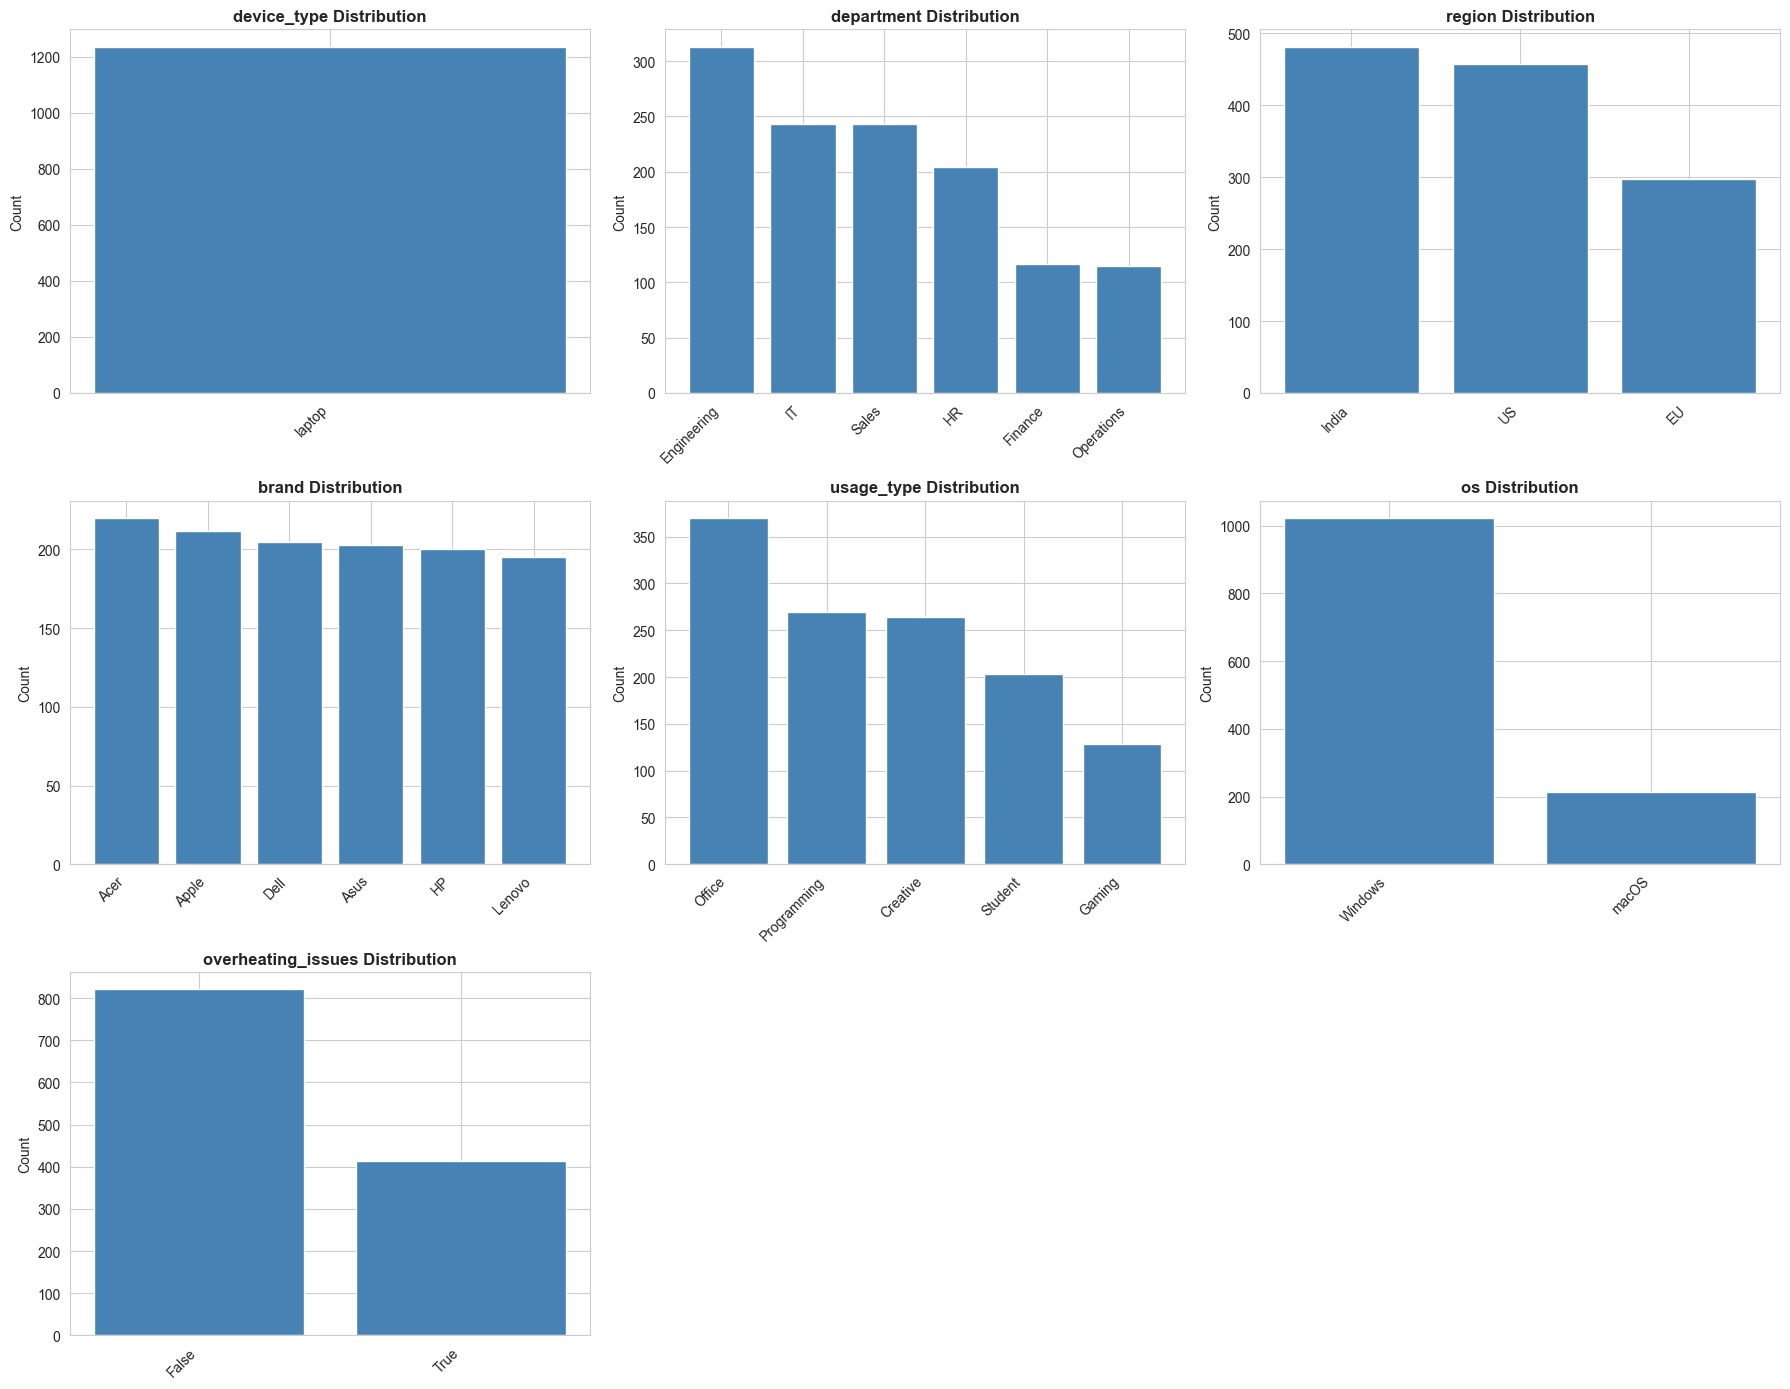

In [15]:
# Visualize categorical features
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, col in enumerate(categorical_features):
    if idx < len(axes):
        value_counts = df[col].value_counts()
        axes[idx].bar(range(len(value_counts)), value_counts.values, color='steelblue')
        axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[idx].set_ylabel('Count')

# Hide unused subplots
for idx in range(len(categorical_features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Numerical Features Analysis

In [16]:
# Identify numerical features
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude ID and date-related columns
exclude_cols = ['asset_id', 'model_year', 'data_completeness']
numerical_features = [col for col in numerical_features if col not in exclude_cols and not col.endswith('_id')]

print(f"Numerical Features ({len(numerical_features)}):")
print(numerical_features)

Numerical Features (18):
['age_in_months', 'battery_cycles', 'battery_health_percent', 'smart_sectors_reallocated', 'thermal_events_count', 'daily_usage_hours', 'performance_rating', 'total_incidents', 'critical_incidents', 'high_incidents', 'medium_incidents', 'low_incidents', 'avg_resolution_time_hours', 'incident_rate_per_month', 'critical_incident_ratio', 'battery_degradation_rate', 'thermal_events_per_month', 'risk_score']


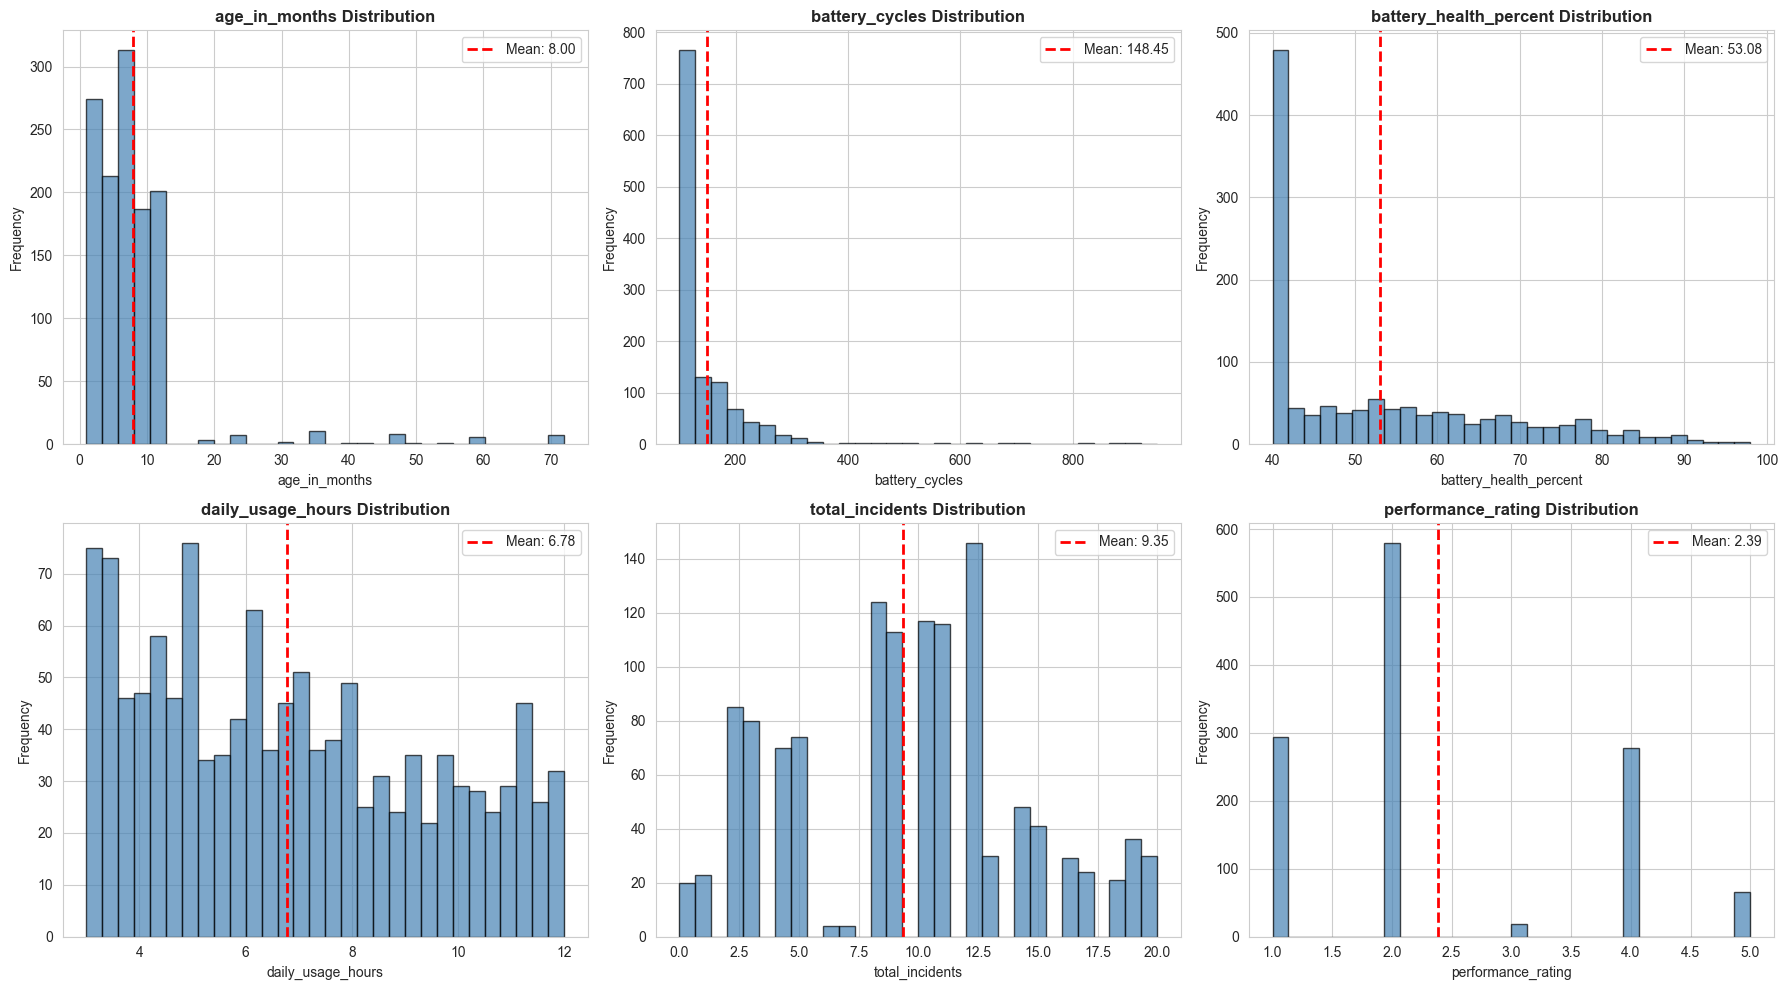

In [17]:
# Distribution of key numerical features
key_features = ['age_in_months', 'battery_cycles', 'battery_health_percent', 
                'daily_usage_hours', 'total_incidents', 'performance_rating']
key_features = [col for col in key_features if col in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(key_features):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.2f}')
        axes[idx].legend()

plt.tight_layout()
plt.show()

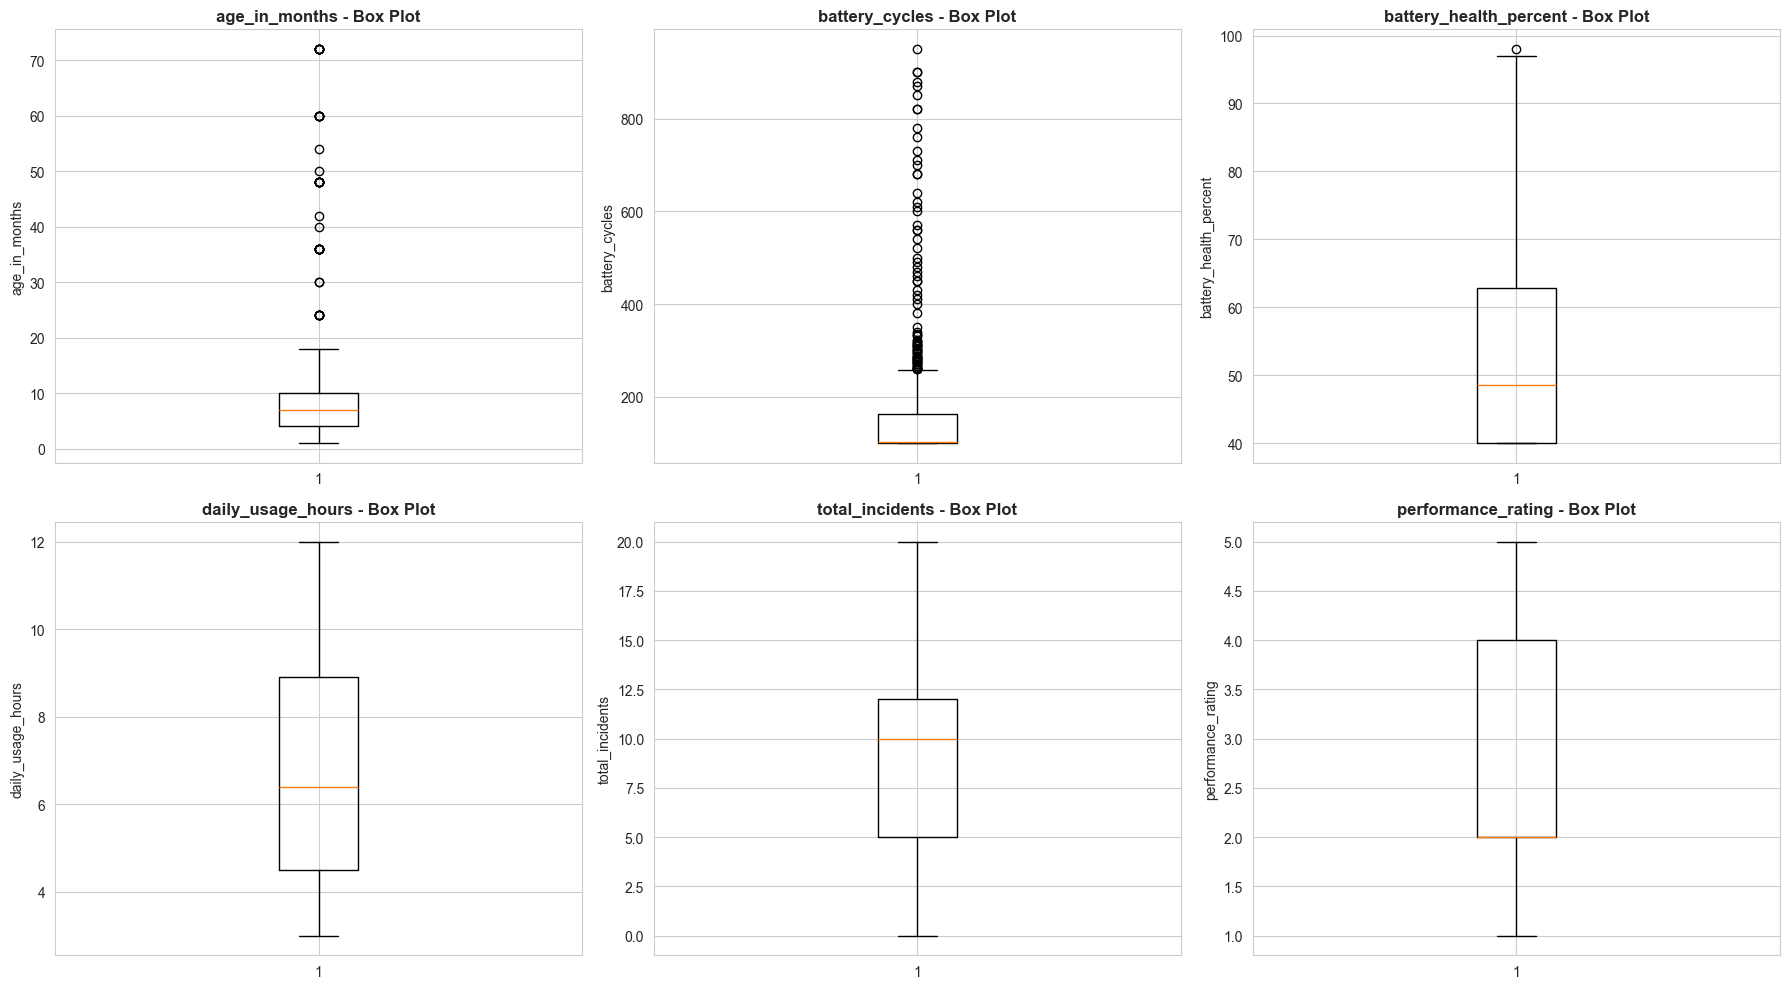

In [18]:
# Box plots for outlier detection
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(key_features):
    if idx < len(axes):
        axes[idx].boxplot(df[col].dropna(), vert=True)
        axes[idx].set_title(f'{col} - Box Plot', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

## 8. Outlier Detection

In [19]:
# Detect outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("Outlier Analysis (IQR Method):")
print("=" * 80)

outlier_summary = []

for col in key_features:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    outlier_summary.append({
        'Feature': col,
        'Outlier Count': len(outliers),
        'Outlier %': f"{len(outliers) / len(df) * 100:.2f}%",
        'Lower Bound': f"{lower:.2f}",
        'Upper Bound': f"{upper:.2f}"
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

Outlier Analysis (IQR Method):


,Feature,Outlier Count,Outlier %,Lower Bound,Upper Bound
0,age_in_months,44,3.56%,-5.00,19.00
1,battery_cycles,79,6.40%,5.50,257.50
2,battery_health_percent,1,0.08%,5.76,97.07
3,daily_usage_hours,0,0.00%,-2.10,15.50
4,total_incidents,0,0.00%,-5.50,22.50
5,performance_rating,0,0.00%,-1.00,7.00


## 9. Feature Correlations

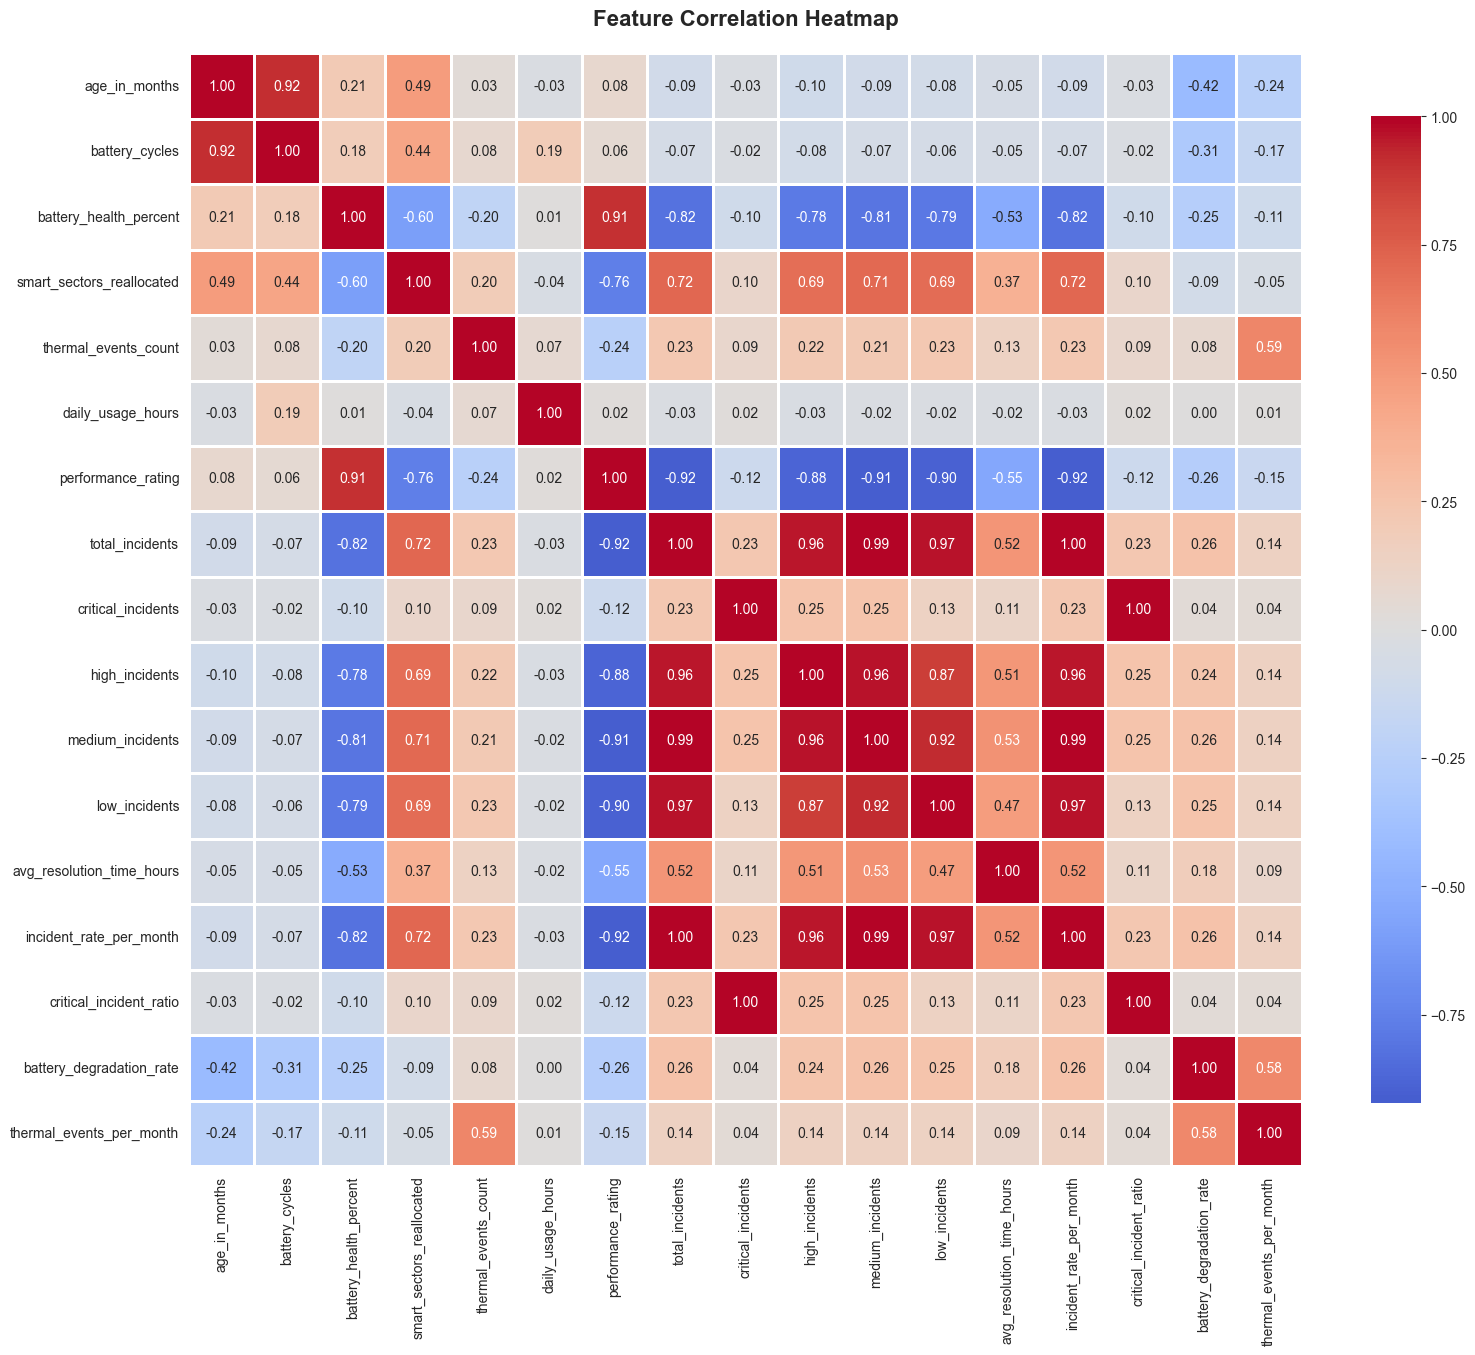

In [20]:
# Correlation matrix for numerical features
correlation_features = [col for col in numerical_features if col != 'risk_score']

if len(correlation_features) > 1:
    correlation_matrix = df[correlation_features].corr()
    
    plt.figure(figsize=(16, 14))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()


Correlation with Risk Score (Target Variable):


,Feature,Correlation
0,risk_score,1.0000
1,incident_rate_per_month,0.8489
2,total_incidents,0.8488
3,smart_sectors_reallocated,0.8421
4,medium_incidents,0.8358
5,low_incidents,0.8259
6,high_incidents,0.8137
7,thermal_events_count,0.5835
8,avg_resolution_time_hours,0.4728
9,thermal_events_per_month,0.2642


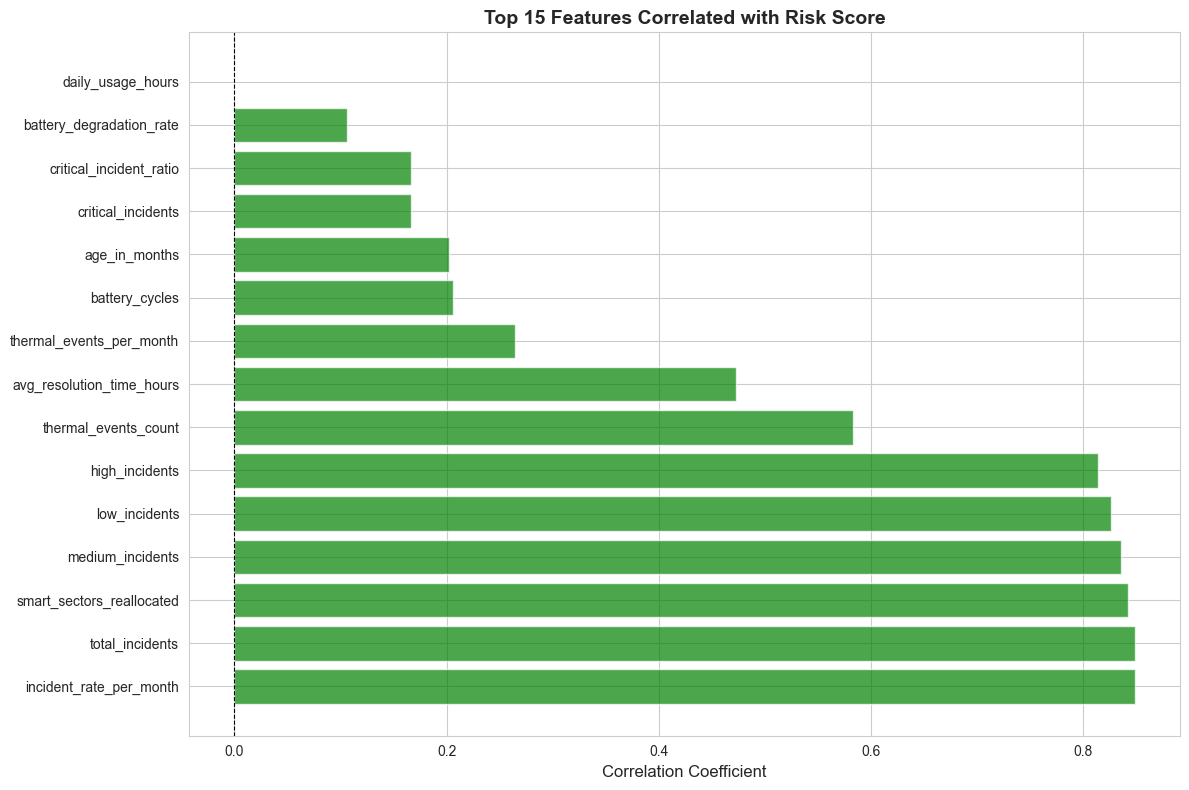

In [21]:
# Correlations with risk_score (target)
if 'risk_score' in df.columns:
    print("\nCorrelation with Risk Score (Target Variable):")
    print("=" * 80)
    
    risk_correlations = df[numerical_features].corrwith(df['risk_score']).sort_values(ascending=False)
    risk_correlations_df = pd.DataFrame({
        'Feature': risk_correlations.index,
        'Correlation': risk_correlations.values
    })
    
    display(risk_correlations_df)
    
    # Visualize top correlations
    plt.figure(figsize=(12, 8))
    top_n = min(15, len(risk_correlations) - 1)  # Exclude risk_score itself
    top_corr = risk_correlations[risk_correlations.index != 'risk_score'].head(top_n)
    
    colors = ['red' if x < 0 else 'green' for x in top_corr.values]
    plt.barh(range(len(top_corr)), top_corr.values, color=colors, alpha=0.7)
    plt.yticks(range(len(top_corr)), top_corr.index)
    plt.xlabel('Correlation Coefficient', fontsize=12)
    plt.title(f'Top {top_n} Features Correlated with Risk Score', fontsize=14, fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    plt.tight_layout()
    plt.show()

## 10. Data Quality Issues

In [22]:
# Check for duplicate records
print("Duplicate Records Check:")
print("=" * 80)

duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

if 'asset_id' in df.columns:
    duplicate_assets = df['asset_id'].duplicated().sum()
    print(f"Duplicate asset_ids: {duplicate_assets}")
    
if duplicates > 0:
    print("\n⚠️  WARNING: Duplicate records found!")
else:
    print("\n✓ No duplicate records found.")

Duplicate Records Check:
Total duplicate rows: 0
Duplicate asset_ids: 0

✓ No duplicate records found.


In [23]:
# Check for invalid values
print("\nData Validity Checks:")
print("=" * 80)

validity_issues = []

# Battery health should be between 0 and 100
if 'battery_health_percent' in df.columns:
    invalid_battery = df[(df['battery_health_percent'] < 0) | (df['battery_health_percent'] > 100)]
    if len(invalid_battery) > 0:
        validity_issues.append(f"Battery health out of range: {len(invalid_battery)} records")

# Age should be positive
if 'age_in_months' in df.columns:
    invalid_age = df[df['age_in_months'] < 0]
    if len(invalid_age) > 0:
        validity_issues.append(f"Negative age: {len(invalid_age)} records")

# Daily usage hours should be between 0 and 24
if 'daily_usage_hours' in df.columns:
    invalid_usage = df[(df['daily_usage_hours'] < 0) | (df['daily_usage_hours'] > 24)]
    if len(invalid_usage) > 0:
        validity_issues.append(f"Daily usage hours out of range: {len(invalid_usage)} records")

# Performance rating should be between 1 and 5
if 'performance_rating' in df.columns:
    invalid_rating = df[(df['performance_rating'] < 1) | (df['performance_rating'] > 5)]
    if len(invalid_rating) > 0:
        validity_issues.append(f"Performance rating out of range: {len(invalid_rating)} records")

if validity_issues:
    print("⚠️  Data validity issues found:")
    for issue in validity_issues:
        print(f"  - {issue}")
else:
    print("✓ No data validity issues detected.")


Data Validity Checks:
✓ No data validity issues detected.


In [24]:
# Check for zero/negative values in key metrics
print("\nZero/Negative Value Analysis:")
print("=" * 80)

metrics = ['battery_cycles', 'total_incidents', 'avg_resolution_time_hours']
metrics = [col for col in metrics if col in df.columns]

for col in metrics:
    zero_count = (df[col] == 0).sum()
    negative_count = (df[col] < 0).sum()
    print(f"{col}:")
    print(f"  Zero values: {zero_count} ({zero_count/len(df)*100:.2f}%)")
    print(f"  Negative values: {negative_count} ({negative_count/len(df)*100:.2f}%)")


Zero/Negative Value Analysis:
battery_cycles:
  Zero values: 0 (0.00%)
  Negative values: 0 (0.00%)
total_incidents:
  Zero values: 20 (1.62%)
  Negative values: 0 (0.00%)
avg_resolution_time_hours:
  Zero values: 20 (1.62%)
  Negative values: 0 (0.00%)


## 11. Temporal Analysis

In [25]:
# Analyze date-related columns
date_columns = ['purchase_date', 'created_at']
date_columns = [col for col in date_columns if col in df.columns]

if date_columns:
    print("Temporal Analysis:")
    print("=" * 80)
    
    for col in date_columns:
        # Convert to datetime
        df[col] = pd.to_datetime(df[col], errors='coerce')
        
        print(f"\n{col.upper()}:")
        print(f"  Earliest: {df[col].min()}")
        print(f"  Latest: {df[col].max()}")
        print(f"  Date range: {(df[col].max() - df[col].min()).days} days")

Temporal Analysis:

PURCHASE_DATE:
  Earliest: 2020-03-31 15:45:16.304690
  Latest: 2026-01-29 15:59:08.182415
  Date range: 2130 days

CREATED_AT:
  Earliest: 2026-02-28 15:45:16.302142
  Latest: 2026-02-28 15:59:08.182415
  Date range: 0 days


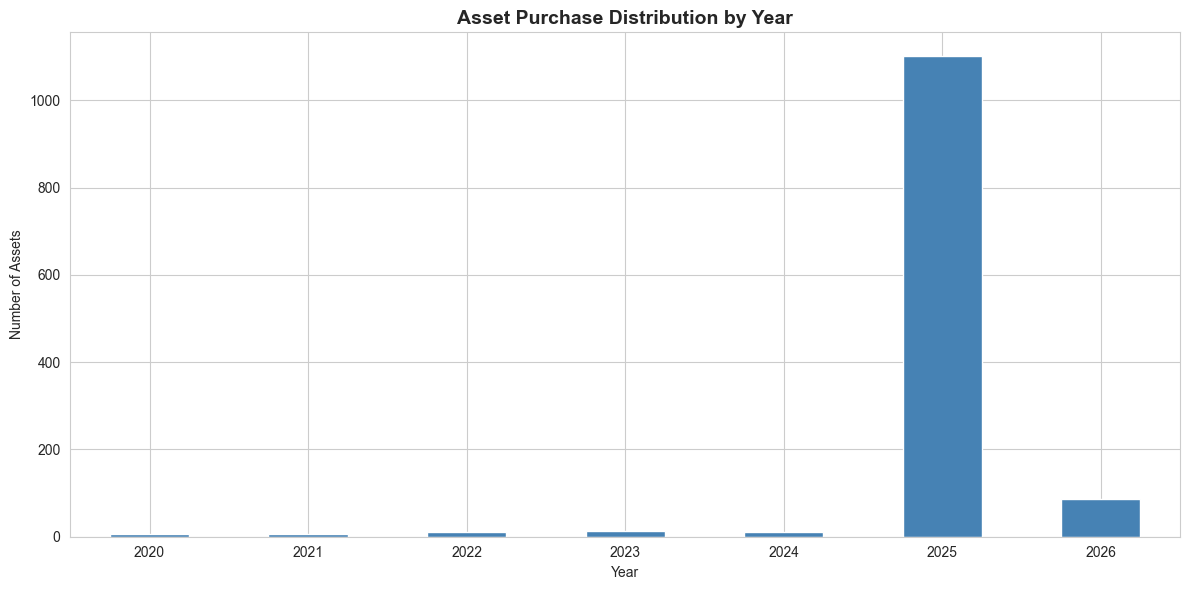

In [26]:
# Visualize purchase date distribution
if 'purchase_date' in df.columns:
    df['purchase_year'] = df['purchase_date'].dt.year
    
    plt.figure(figsize=(12, 6))
    df['purchase_year'].value_counts().sort_index().plot(kind='bar', color='steelblue')
    plt.title('Asset Purchase Distribution by Year', fontsize=14, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Number of Assets')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 12. Summary Report

In [27]:
# Generate comprehensive summary report
print("=" * 80)
print("DATA QUALITY SUMMARY REPORT")
print("=" * 80)

print(f"\n📊 DATASET OVERVIEW")
print(f"  • Total Records: {len(df):,}")
print(f"  • Total Features: {len(df.columns)}")
print(f"  • Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n📋 DATA COMPLETENESS")
missing_count = df.isnull().sum().sum()
if missing_count > 0:
    print(f"  ⚠️  Missing Values: {missing_count:,} ({missing_count/(len(df)*len(df.columns))*100:.2f}% of all values)")
else:
    print(f"  ✓ No missing values detected")

print(f"\n🎯 TARGET VARIABLE")
if 'risk_label' in df.columns:
    risk_dist = df['risk_label'].value_counts()
    for label, count in risk_dist.items():
        print(f"  • {label}: {count} ({count/len(df)*100:.1f}%)")

print(f"\n📈 NUMERICAL FEATURES")
print(f"  • Count: {len(numerical_features)}")
print(f"  • Features: {', '.join(numerical_features[:10])}..." if len(numerical_features) > 10 else f"  • Features: {', '.join(numerical_features)}")

print(f"\n🏷️  CATEGORICAL FEATURES")
categorical_count = len(df.select_dtypes(include=['object', 'bool']).columns)
print(f"  • Count: {categorical_count}")

print(f"\n⚠️  DATA QUALITY ISSUES")
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    print(f"  • Duplicates: {duplicate_count}")
if validity_issues:
    for issue in validity_issues:
        print(f"  • {issue}")
if not duplicate_count and not validity_issues:
    print(f"  ✓ No major data quality issues detected")

print(f"\n💡 RECOMMENDATIONS")
recommendations = []

if 'risk_label' in df.columns:
    risk_pct = df['risk_label'].value_counts(normalize=True) * 100
    max_pct = risk_pct.max()
    min_pct = risk_pct.min()
    if max_pct / min_pct > 3:
        recommendations.append("Consider using class balancing techniques (SMOTE, oversampling, etc.)")

if missing_count > 0:
    recommendations.append("Address missing values before model training")

if duplicate_count > 0:
    recommendations.append("Remove or investigate duplicate records")

# Check for high correlation features
if len(correlation_features) > 1:
    high_corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.9:
                high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j]))
    if high_corr_pairs:
        recommendations.append(f"Found {len(high_corr_pairs)} highly correlated feature pairs - consider feature selection")

recommendations.append("Perform feature engineering to create new predictive features")
recommendations.append("Consider feature scaling/normalization for model training")
recommendations.append("Split data into train/validation/test sets with stratification")

for i, rec in enumerate(recommendations, 1):
    print(f"  {i}. {rec}")

print("\n" + "=" * 80)
print(f"Report generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)

DATA QUALITY SUMMARY REPORT

📊 DATASET OVERVIEW
  • Total Records: 1,235
  • Total Features: 32
  • Memory Usage: 0.73 MB

📋 DATA COMPLETENESS
  ✓ No missing values detected

🎯 TARGET VARIABLE
  • high: 1092 (88.4%)
  • medium: 120 (9.7%)
  • low: 23 (1.9%)

📈 NUMERICAL FEATURES
  • Count: 18
  • Features: age_in_months, battery_cycles, battery_health_percent, smart_sectors_reallocated, thermal_events_count, daily_usage_hours, performance_rating, total_incidents, critical_incidents, high_incidents...

🏷️  CATEGORICAL FEATURES
  • Count: 9

⚠️  DATA QUALITY ISSUES
  ✓ No major data quality issues detected

💡 RECOMMENDATIONS
  1. Consider using class balancing techniques (SMOTE, oversampling, etc.)
  2. Found 15 highly correlated feature pairs - consider feature selection
  3. Perform feature engineering to create new predictive features
  4. Consider feature scaling/normalization for model training
  5. Split data into train/validation/test sets with stratification

Report generated: 20

## 13. Export Analysis Results

In [28]:
# Optional: Export key statistics to CSV
export_stats = df.describe().T
export_stats.to_csv('data_statistics_summary.csv')
print("✓ Statistics exported to 'data_statistics_summary.csv'")

# Optional: Export correlation matrix
if len(correlation_features) > 1:
    correlation_matrix.to_csv('feature_correlations.csv')
    print("✓ Correlation matrix exported to 'feature_correlations.csv'")

✓ Statistics exported to 'data_statistics_summary.csv'
✓ Correlation matrix exported to 'feature_correlations.csv'
